# 🏥 Análise Completa - Beira-Mar Analytics
## Clínica de Estética - Análise de No-Show e Fatores de Influência

**Objetivo:** Analisar padrões de faltas (no-show) em consultas de estética e identificar fatores que influenciam o comportamento dos clientes.

---

## 📦 1. Importação de Bibliotecas e Configurações

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# Configurações
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Configurar exibição do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 📂 2. Carregamento dos Dados

In [ ]:
# Carregar o dataset
# SUBSTITUA pelo caminho do seu arquivo CSV
df = pd.read_csv('../../dados/refined/cancelamentos_com_clima.csv')

print(f"📊 Dataset carregado com sucesso!")
print(f"📏 Dimensões: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"\n📋 Primeiras linhas:")
df.head()

📊 Dataset carregado com sucesso!
📏 Dimensões: 71,839 linhas x 26 colunas

📋 Primeiras linhas:


,ID,PATIENTID,APPOINTMENTID,GENDER,SCHEDULEDDAY,APPOINTMENTDAY,AGE,NEIGHBOURHOOD,SCHOLARSHIP,SERVICENAME,PRICE,DURATION,HIPERTENSION,DIABETES,HANDCAP,SMS_RECEIVED,NO-SHOW,CHAVE_HORA,PRECIPITACAO_MM,TEMP_AR_C,TEMP_MAX_C,TEMP_MIN_C,UMIDADE_RELATIVA,ESTACAO_ANO,CLASSIFICACAO_TEMP,DATA_HORA_CLIMA
0,0,29872499824296.00,5642903,F,2016-04-29 18:38:08,29/04/2016 00:00:00,62,JARDIM DA PENHA,0,DESIGN DE SOBRANCELHAS COM HENNA,45.00,90,1,0,0,1,0,2016-04-29 18:00:00,0.00,15.20,16.50,15.20,77.00,OUTONO,FRIO,2016-04-29 18:00:00
1,2,4262962299951.00,5642549,F,2016-04-29 16:19:04,29/04/2016 00:00:00,62,MATA DA PRAIA,0,APLICACAO DE ENZIMAS,180.00,60,0,0,0,1,0,2016-04-29 16:00:00,0.00,16.30,16.30,15.80,72.00,OUTONO,FRIO,2016-04-29 16:00:00
2,3,867951213174.00,5642828,F,2016-04-29 17:29:31,29/04/2016 00:00:00,8,PONTAL DE CAMBURI,0,DESIGN DE SOBRANCELHAS COM HENNA,45.00,90,0,0,0,1,0,2016-04-29 17:00:00,0.00,16.40,16.40,16.10,72.00,OUTONO,FRIO,2016-04-29 17:00:00
3,4,8841186448183.00,5642494,F,2016-04-29 16:07:23,29/04/2016 00:00:00,56,JARDIM DA PENHA,0,LIMPEZA DE PELE,150.00,120,1,1,0,1,0,2016-04-29 16:00:00,0.00,16.30,16.30,15.80,72.00,OUTONO,FRIO,2016-04-29 16:00:00
4,5,95985133231274.00,5626772,F,2016-04-27 08:36:51,29/04/2016 00:00:00,76,REPUBLICA,0,DRENAGEM LINFATICA,100.00,60,1,0,0,1,0,2016-04-27 08:00:00,0.00,20.00,20.10,20.00,76.00,OUTONO,AGRADAVEL,2016-04-27 08:00:00


## 🔍 3. Análise Exploratória Inicial

In [19]:
# Informações gerais do dataset
print("="*70)
print("📊 INFORMAÇÕES GERAIS DO DATASET")
print("="*70)

print(f"\n📅 Período dos dados:")
print(f"   De: {df['APPOINTMENTDAY'].min()}")
print(f"   Até: {df['APPOINTMENTDAY'].max()}")

print(f"\n👥 Pacientes únicos: {df['PATIENTID'].nunique():,}")
print(f"📅 Agendamentos únicos: {df['APPOINTMENTID'].nunique():,}")
print(f"🏷️ Serviços oferecidos: {df['SERVICENAME'].nunique()}")

print(f"\n❌ Taxa de No-Show Geral: {df['NO-SHOW'].mean()*100:.2f}%")
print(f"✅ Taxa de Comparecimento: {(1-df['NO-SHOW'].mean())*100:.2f}%")

📊 INFORMAÇÕES GERAIS DO DATASET

📅 Período dos dados:
   De: 01/06/2016 00:00:00
   Até: 31/05/2016 00:00:00

👥 Pacientes únicos: 40,045
📅 Agendamentos únicos: 71,839
🏷️ Serviços oferecidos: 11

❌ Taxa de No-Show Geral: 20.31%
✅ Taxa de Comparecimento: 79.69%


In [8]:
# Tipos de dados e valores ausentes
print("\n📋 Tipos de Dados e Valores Ausentes:")
info_df = pd.DataFrame({
    'Tipo': df.dtypes,
    'Não-Nulos': df.count(),
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
info_df


📋 Tipos de Dados e Valores Ausentes:


,Tipo,Não-Nulos,Nulos,% Nulos
ID,int64,71839,0,0.00
PATIENTID,float64,71839,0,0.00
APPOINTMENTID,int64,71839,0,0.00
GENDER,object,71839,0,0.00
SCHEDULEDDAY,object,71839,0,0.00
APPOINTMENTDAY,object,71839,0,0.00
AGE,int64,71839,0,0.00
NEIGHBOURHOOD,object,71839,0,0.00
SCHOLARSHIP,int64,71839,0,0.00
SERVICENAME,object,71839,0,0.00


In [9]:
# Estatísticas descritivas
print("\n📈 Estatísticas Descritivas:")
df.describe()


📈 Estatísticas Descritivas:


,ID,PATIENTID,APPOINTMENTID,AGE,SCHOLARSHIP,PRICE,DURATION,HIPERTENSION,DIABETES,HANDCAP,SMS_RECEIVED,NO-SHOW,PRECIPITACAO_MM,TEMP_AR_C,TEMP_MAX_C,TEMP_MIN_C,UMIDADE_RELATIVA
count,71839.00,71839.00,71839.00,71839.00,71839.00,71839.00,71839.00,71839.00,71839.00,71839.00,71839.00,71839.00,71794.00,71794.00,71794.00,71794.00,71794.00
mean,55682.31,146009116689541.09,5674336.02,38.89,0.12,104.67,74.70,0.21,0.08,0.02,0.66,0.20,0.20,18.21,18.55,17.61,74.78
std,31667.65,254955085929863.97,72015.49,22.15,0.33,51.99,38.25,0.41,0.27,0.15,0.47,0.40,1.10,4.22,4.30,3.94,14.23
min,0.00,39217.84,5030230.00,0.00,0.00,30.00,30.00,0.00,0.00,0.00,0.00,0.00,0.00,10.10,10.10,10.00,22.00
25%,28162.50,3974210698544.50,5639221.50,21.00,0.00,45.00,40.00,0.00,0.00,0.00,0.00,0.00,0.00,15.20,15.40,14.90,66.00
50%,56091.00,29872499824296.00,5679849.00,39.00,0.00,100.00,60.00,0.00,0.00,0.00,1.00,0.00,0.00,17.50,17.70,17.00,81.00
75%,83233.50,93957433871712.00,5724902.00,56.00,0.00,150.00,120.00,0.00,0.00,0.00,1.00,0.00,0.00,21.00,21.20,20.00,85.00
max,110526.00,999981631772427.00,5790484.00,115.00,1.00,180.00,150.00,1.00,1.00,4.00,1.00,1.00,14.40,32.10,32.80,31.30,94.00


## 📊 4. Análise de No-Show

### 4.1 Distribuição Geral

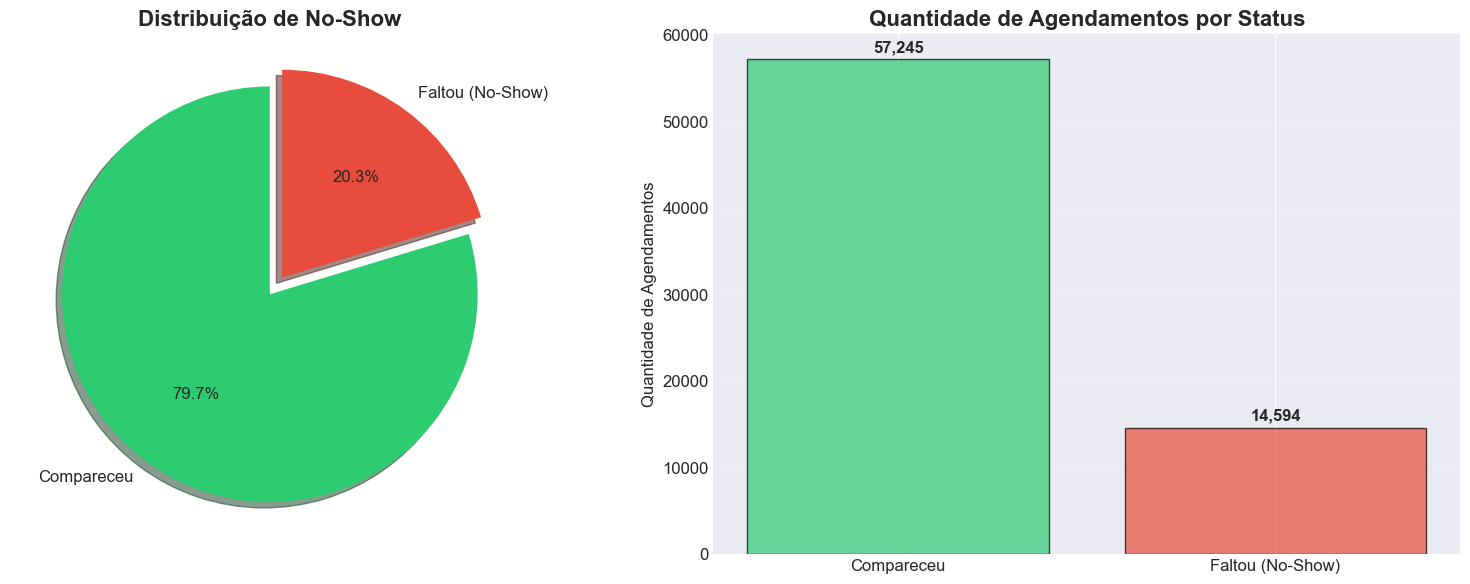


📊 Resumo:
   ✅ Comparecimentos: 57,245 (79.7%)
   ❌ No-Shows: 14,594 (20.3%)


In [10]:
# Visualização da distribuição de No-Show
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de pizza
no_show_counts = df['NO-SHOW'].value_counts()
labels = ['Compareceu', 'Faltou (No-Show)']
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)

axes[0].pie(no_show_counts, labels=labels, autopct='%1.1f%%', 
            colors=colors, explode=explode, startangle=90, shadow=True)
axes[0].set_title('Distribuição de No-Show', fontsize=16, fontweight='bold')

# Gráfico de barras
axes[1].bar(labels, no_show_counts, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Quantidade de Agendamentos', fontsize=12)
axes[1].set_title('Quantidade de Agendamentos por Status', fontsize=16, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, v in enumerate(no_show_counts):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Resumo:")
print(f"   ✅ Comparecimentos: {no_show_counts[0]:,} ({no_show_counts[0]/len(df)*100:.1f}%)")
print(f"   ❌ No-Shows: {no_show_counts[1]:,} ({no_show_counts[1]/len(df)*100:.1f}%)")

### 4.3 No-Show por Faixa Etária

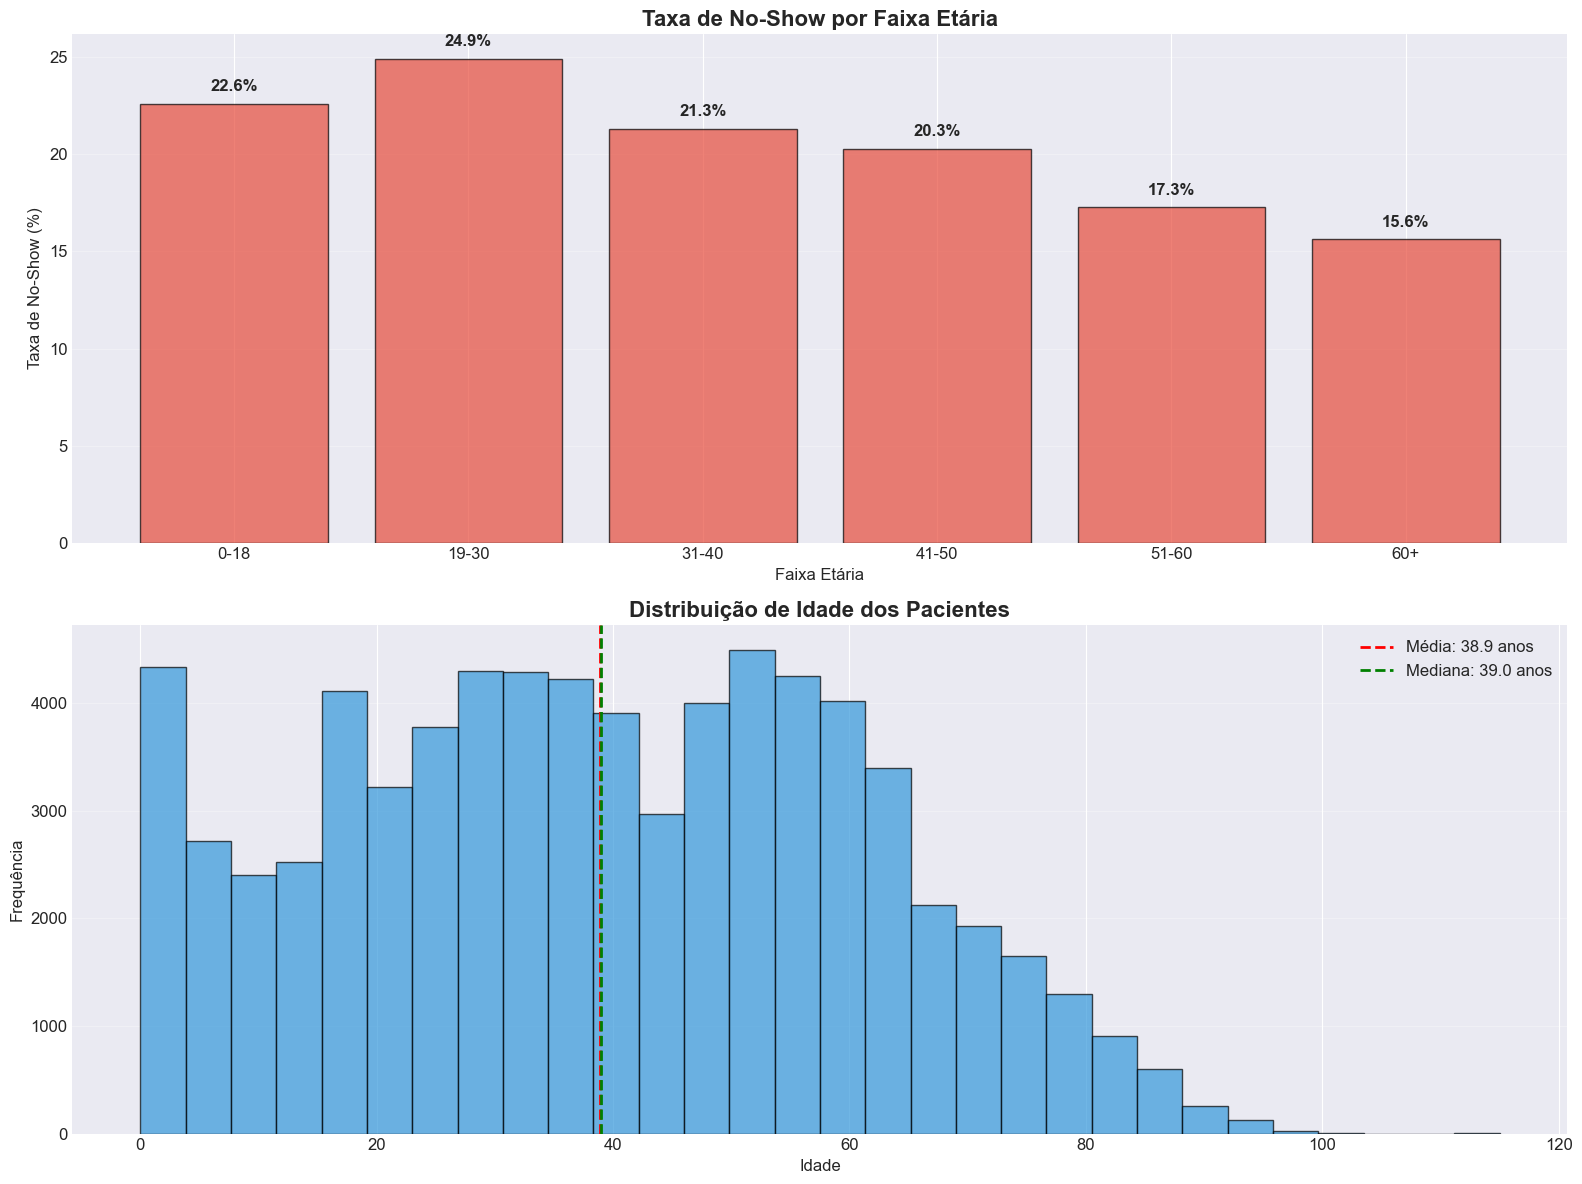


📊 Estatísticas de Idade:
   Média: 38.9 anos
   Mediana: 39.0 anos
   Mínima: 0 anos
   Máxima: 115 anos


In [11]:
# Criar faixas etárias
bins = [0, 18, 30, 40, 50, 60, 100]
labels = ['0-18', '19-30', '31-40', '41-50', '51-60', '60+']
df['FAIXA_ETARIA'] = pd.cut(df['AGE'], bins=bins, labels=labels)

# Análise por faixa etária
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Taxa de no-show por faixa etária
no_show_age = df.groupby('FAIXA_ETARIA')['NO-SHOW'].agg(['mean', 'count'])
no_show_age['mean'] = no_show_age['mean'] * 100

axes[0].bar(range(len(no_show_age)), no_show_age['mean'], 
            color='#e74c3c', edgecolor='black', alpha=0.7)
axes[0].set_xticks(range(len(no_show_age)))
axes[0].set_xticklabels(no_show_age.index)
axes[0].set_ylabel('Taxa de No-Show (%)', fontsize=12)
axes[0].set_xlabel('Faixa Etária', fontsize=12)
axes[0].set_title('Taxa de No-Show por Faixa Etária', fontsize=16, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, (idx, row) in enumerate(no_show_age.iterrows()):
    axes[0].text(i, row['mean'] + 0.5, f"{row['mean']:.1f}%", 
                ha='center', va='bottom', fontweight='bold')

# Distribuição de idade
axes[1].hist(df['AGE'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[1].axvline(df['AGE'].mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Média: {df["AGE"].mean():.1f} anos')
axes[1].axvline(df['AGE'].median(), color='green', linestyle='--', linewidth=2, 
               label=f'Mediana: {df["AGE"].median():.1f} anos')
axes[1].set_ylabel('Frequência', fontsize=12)
axes[1].set_xlabel('Idade', fontsize=12)
axes[1].set_title('Distribuição de Idade dos Pacientes', fontsize=16, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Estatísticas de Idade:")
print(f"   Média: {df['AGE'].mean():.1f} anos")
print(f"   Mediana: {df['AGE'].median():.1f} anos")
print(f"   Mínima: {df['AGE'].min():.0f} anos")
print(f"   Máxima: {df['AGE'].max():.0f} anos")

## 💰 5. Análise de Serviços e Preços

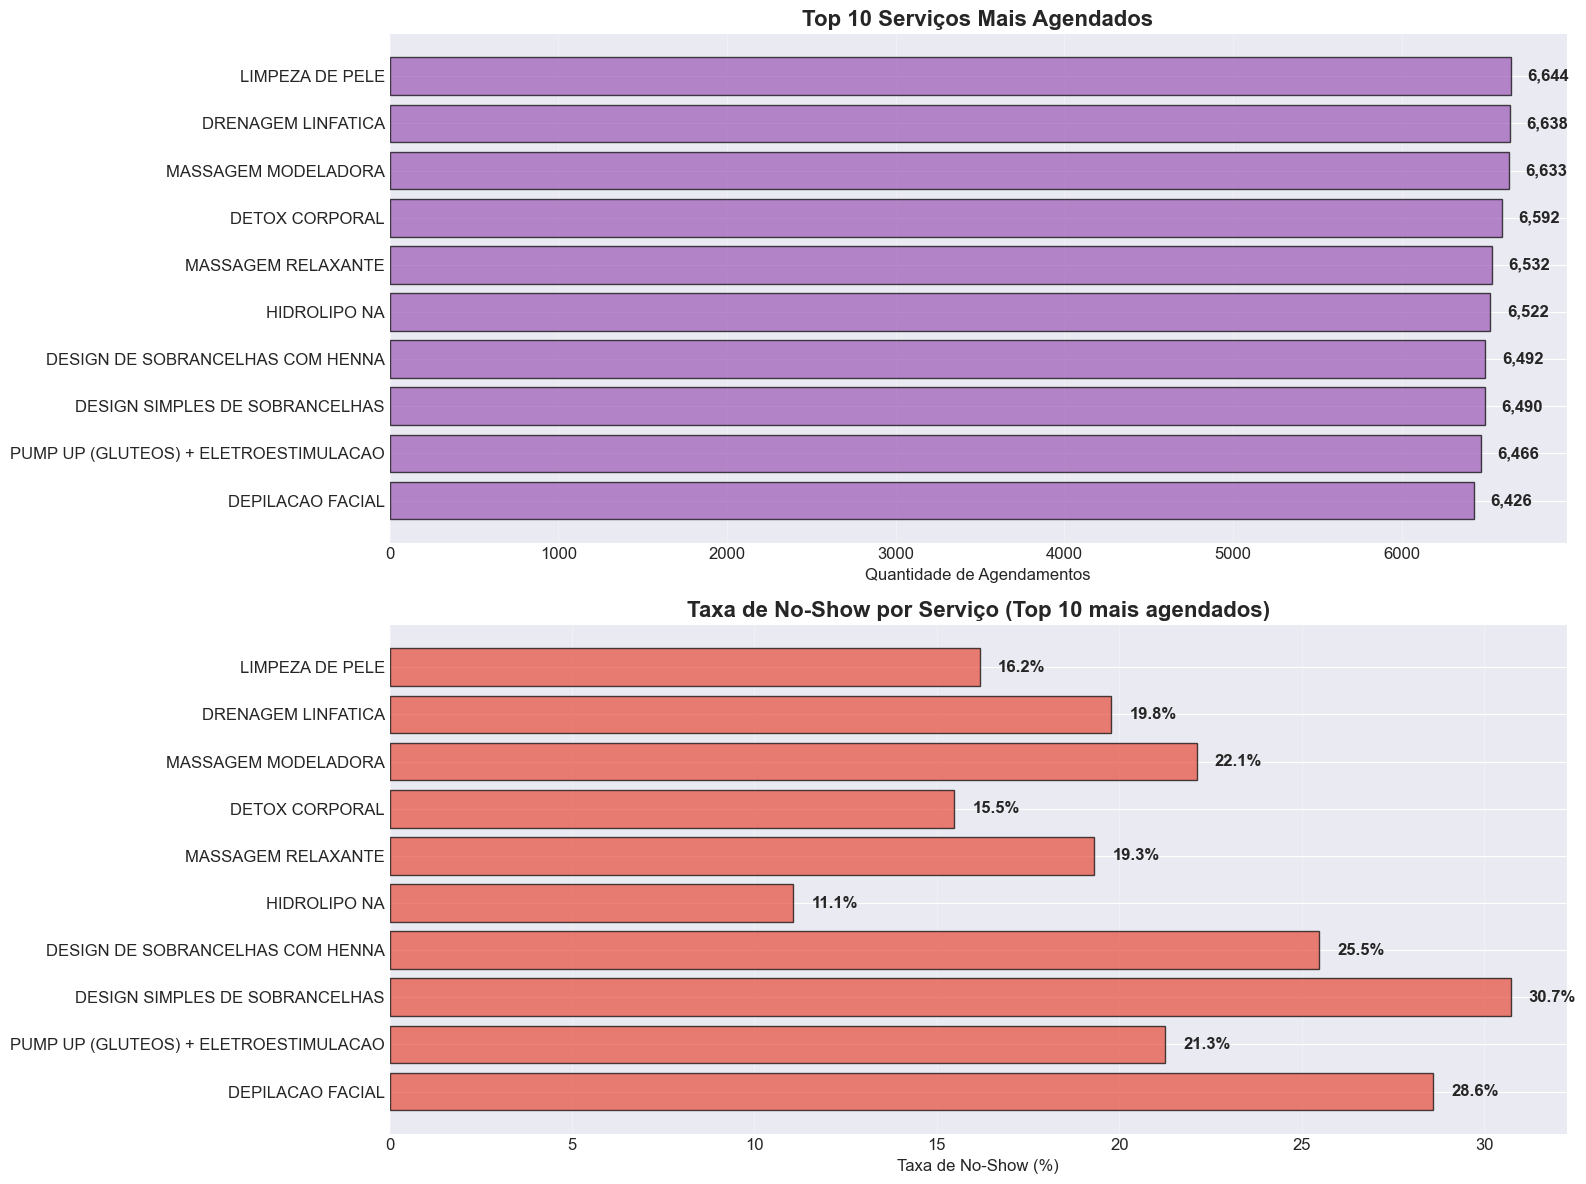

In [12]:
# Top 10 serviços mais agendados
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

top_services = df['SERVICENAME'].value_counts().head(10)

axes[0].barh(range(len(top_services)), top_services.values, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(top_services)))
axes[0].set_yticklabels(top_services.index)
axes[0].set_xlabel('Quantidade de Agendamentos', fontsize=12)
axes[0].set_title('Top 10 Serviços Mais Agendados', fontsize=16, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

for i, v in enumerate(top_services.values):
    axes[0].text(v + 100, i, f'{v:,}', ha='left', va='center', fontweight='bold')

# Taxa de no-show por serviço (top 10)
service_noshow = df.groupby('SERVICENAME')['NO-SHOW'].agg(['mean', 'count']).sort_values('count', ascending=False).head(10)
service_noshow['mean'] = service_noshow['mean'] * 100

axes[1].barh(range(len(service_noshow)), service_noshow['mean'], color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(service_noshow)))
axes[1].set_yticklabels(service_noshow.index)
axes[1].set_xlabel('Taxa de No-Show (%)', fontsize=12)
axes[1].set_title('Taxa de No-Show por Serviço (Top 10 mais agendados)', fontsize=16, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

for i, (idx, row) in enumerate(service_noshow.iterrows()):
    axes[1].text(row['mean'] + 0.5, i, f"{row['mean']:.1f}%", 
                ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

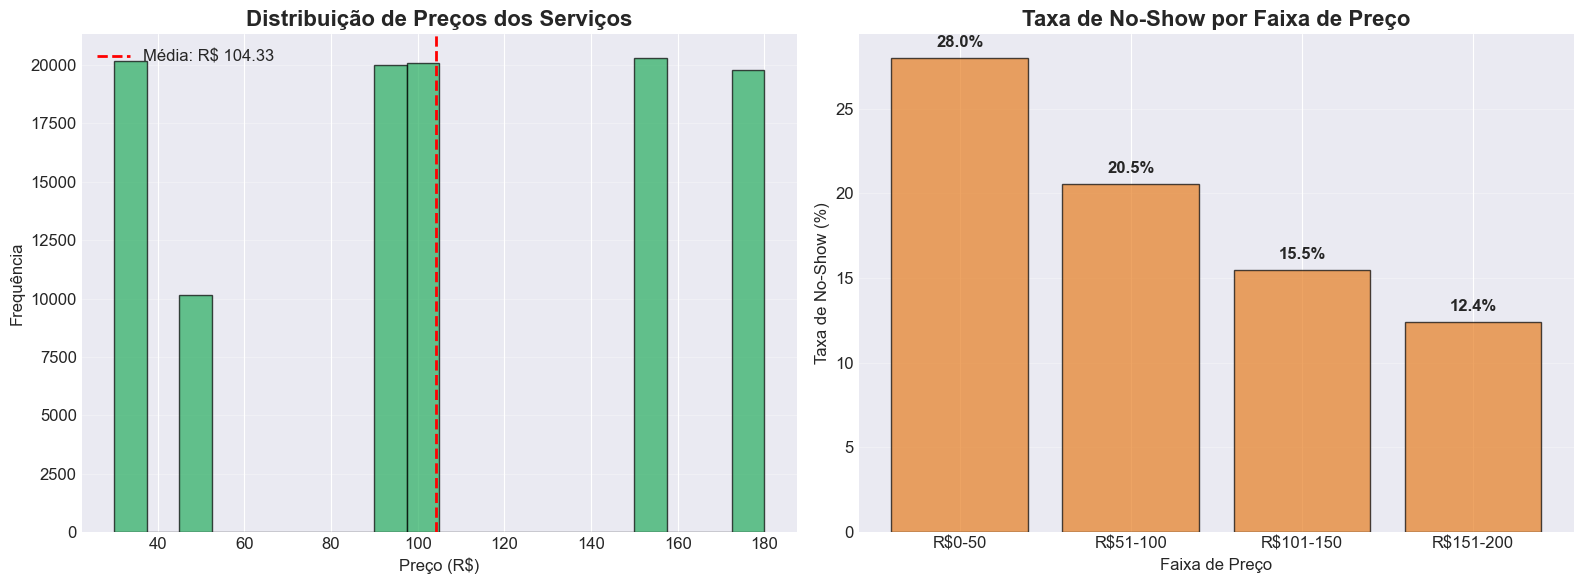


💰 Estatísticas de Preços:
   Preço Médio: R$ 104.33
   Preço Mediano: R$ 100.00
   Preço Mínimo: R$ 30.00
   Preço Máximo: R$ 180.00


In [10]:
# Análise de preços
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribuição de preços
axes[0].hist(df['PRICE'].dropna(), bins=20, color='#27ae60', edgecolor='black', alpha=0.7)
axes[0].axvline(df['PRICE'].mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Média: R$ {df["PRICE"].mean():.2f}')
axes[0].set_xlabel('Preço (R$)', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].set_title('Distribuição de Preços dos Serviços', fontsize=16, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# No-show por faixa de preço
price_bins = [0, 50, 100, 150, 200]
price_labels = ['R$0-50', 'R$51-100', 'R$101-150', 'R$151-200']
df['FAIXA_PRECO'] = pd.cut(df['PRICE'], bins=price_bins, labels=price_labels)

price_noshow = df.groupby('FAIXA_PRECO')['NO-SHOW'].mean() * 100

axes[1].bar(range(len(price_noshow)), price_noshow.values, 
           color='#e67e22', edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(price_noshow)))
axes[1].set_xticklabels(price_noshow.index)
axes[1].set_ylabel('Taxa de No-Show (%)', fontsize=12)
axes[1].set_xlabel('Faixa de Preço', fontsize=12)
axes[1].set_title('Taxa de No-Show por Faixa de Preço', fontsize=16, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(price_noshow.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💰 Estatísticas de Preços:")
print(f"   Preço Médio: R$ {df['PRICE'].mean():.2f}")
print(f"   Preço Mediano: R$ {df['PRICE'].median():.2f}")
print(f"   Preço Mínimo: R$ {df['PRICE'].min():.2f}")
print(f"   Preço Máximo: R$ {df['PRICE'].max():.2f}")

## 🌡️ 6. Análise de Fatores Climáticos

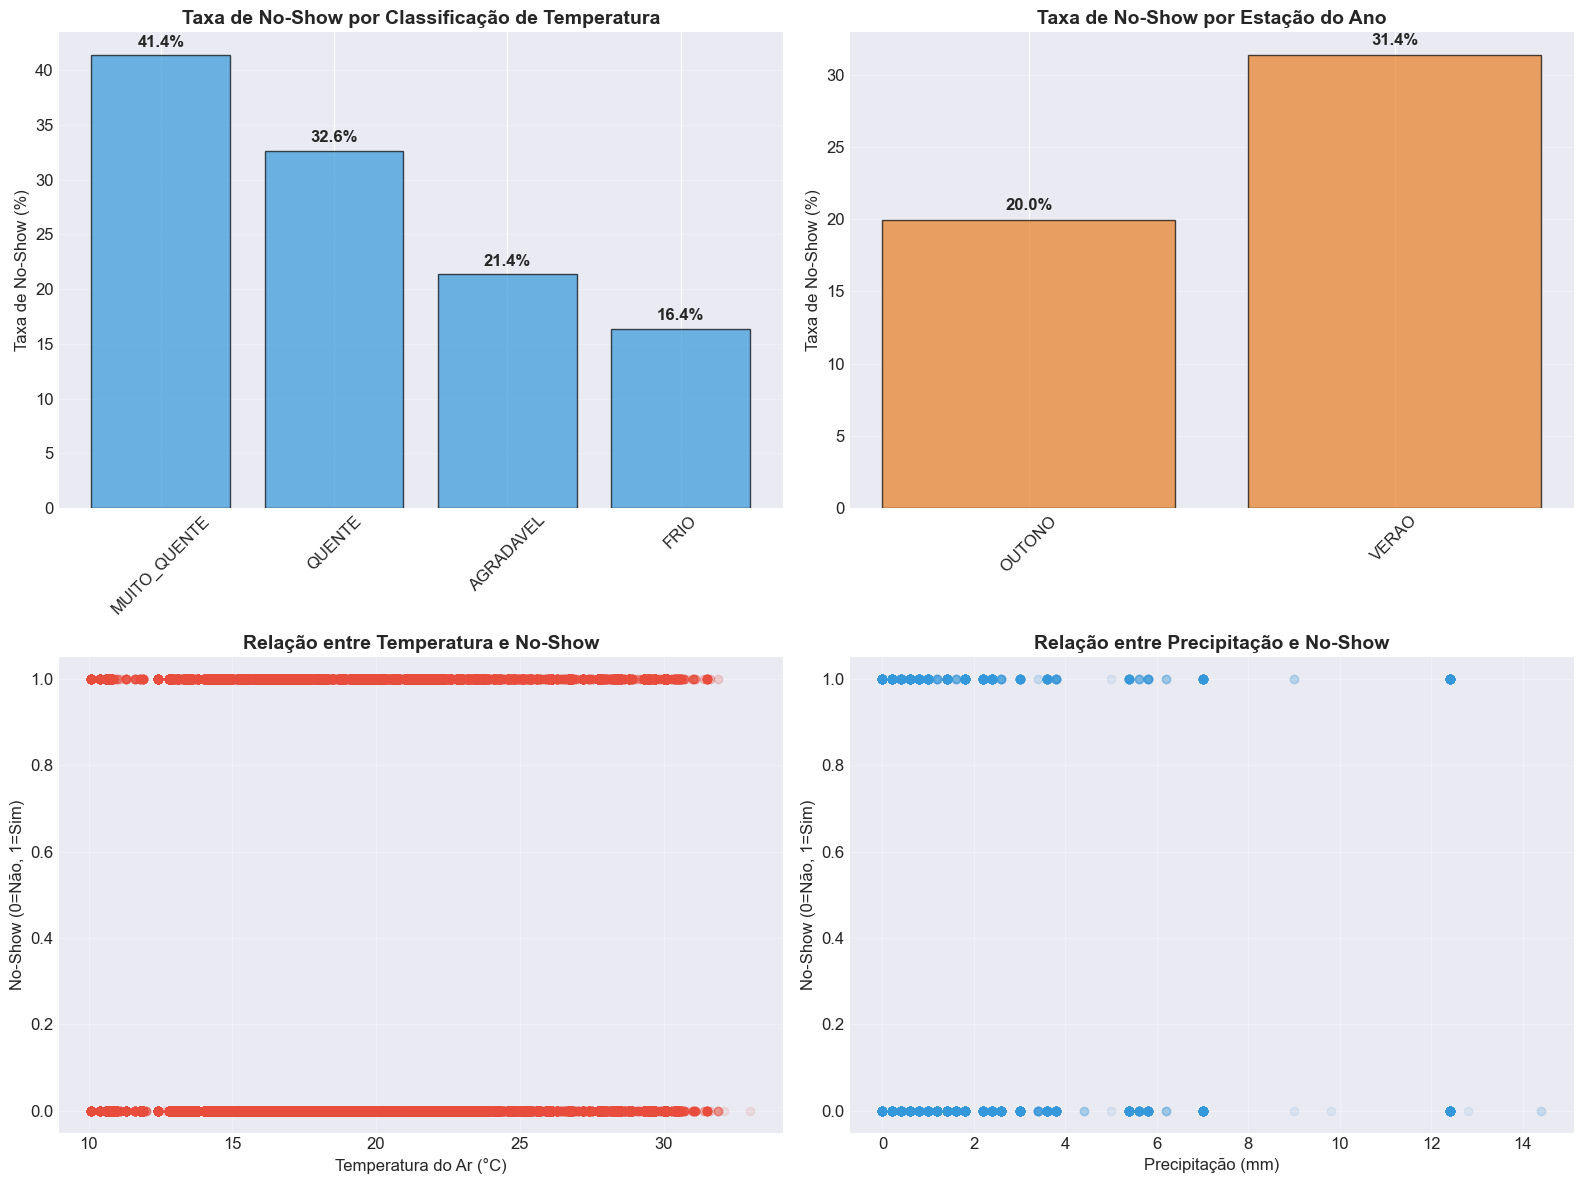

In [11]:
# No-show por classificação de temperatura
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Taxa de no-show por classificação de temperatura
temp_noshow = df.groupby('CLASSIFICACAO_TEMP')['NO-SHOW'].agg(['mean', 'count'])
temp_noshow['mean'] = temp_noshow['mean'] * 100
temp_noshow = temp_noshow.sort_values('mean', ascending=False)

axes[0, 0].bar(range(len(temp_noshow)), temp_noshow['mean'], 
              color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 0].set_xticks(range(len(temp_noshow)))
axes[0, 0].set_xticklabels(temp_noshow.index, rotation=45)
axes[0, 0].set_ylabel('Taxa de No-Show (%)', fontsize=12)
axes[0, 0].set_title('Taxa de No-Show por Classificação de Temperatura', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

for i, (idx, row) in enumerate(temp_noshow.iterrows()):
    axes[0, 0].text(i, row['mean'] + 0.5, f"{row['mean']:.1f}%", 
                   ha='center', va='bottom', fontweight='bold')

# Taxa de no-show por estação do ano
season_noshow = df.groupby('ESTACAO_ANO')['NO-SHOW'].agg(['mean', 'count'])
season_noshow['mean'] = season_noshow['mean'] * 100

axes[0, 1].bar(range(len(season_noshow)), season_noshow['mean'], 
              color='#e67e22', edgecolor='black', alpha=0.7)
axes[0, 1].set_xticks(range(len(season_noshow)))
axes[0, 1].set_xticklabels(season_noshow.index, rotation=45)
axes[0, 1].set_ylabel('Taxa de No-Show (%)', fontsize=12)
axes[0, 1].set_title('Taxa de No-Show por Estação do Ano', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

for i, (idx, row) in enumerate(season_noshow.iterrows()):
    axes[0, 1].text(i, row['mean'] + 0.5, f"{row['mean']:.1f}%", 
                   ha='center', va='bottom', fontweight='bold')

# Correlação temperatura x no-show
axes[1, 0].scatter(df['TEMP_AR_C'], df['NO-SHOW'], alpha=0.1, color='#e74c3c')
axes[1, 0].set_xlabel('Temperatura do Ar (°C)', fontsize=12)
axes[1, 0].set_ylabel('No-Show (0=Não, 1=Sim)', fontsize=12)
axes[1, 0].set_title('Relação entre Temperatura e No-Show', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Correlação precipitação x no-show
axes[1, 1].scatter(df['PRECIPITACAO_MM'], df['NO-SHOW'], alpha=0.1, color='#3498db')
axes[1, 1].set_xlabel('Precipitação (mm)', fontsize=12)
axes[1, 1].set_ylabel('No-Show (0=Não, 1=Sim)', fontsize=12)
axes[1, 1].set_title('Relação entre Precipitação e No-Show', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 📱 7. Análise de SMS e Comunicação

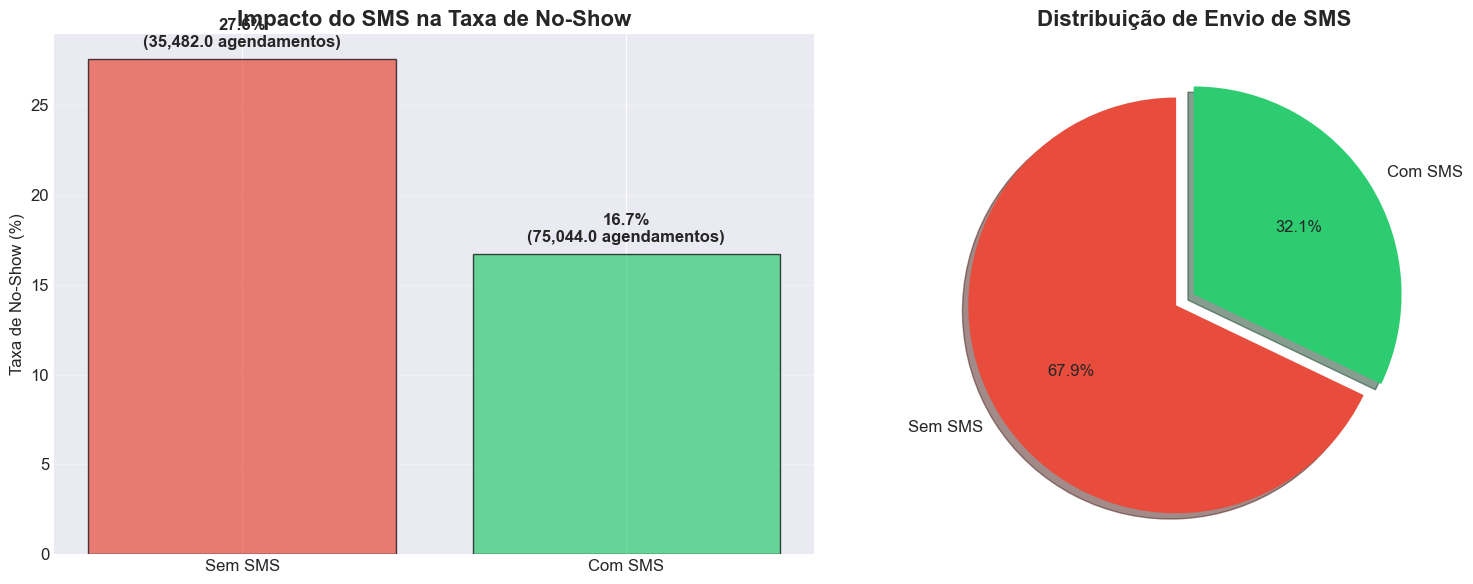


📱 Análise de SMS:
   Sem SMS: 27.57% de no-show (35,482 casos)
   Com SMS: 16.70% de no-show (75,044 casos)
   ✅ Redução de 10.87 pontos percentuais com SMS!


In [12]:
# Impacto do SMS no no-show
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Taxa de no-show com e sem SMS
sms_noshow = df.groupby('SMS_RECEIVED')['NO-SHOW'].agg(['mean', 'count'])
sms_noshow['mean'] = sms_noshow['mean'] * 100
sms_labels = ['Sem SMS', 'Com SMS']

axes[0].bar(range(len(sms_noshow)), sms_noshow['mean'], 
           color=['#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.7)
axes[0].set_xticks(range(len(sms_noshow)))
axes[0].set_xticklabels(sms_labels)
axes[0].set_ylabel('Taxa de No-Show (%)', fontsize=12)
axes[0].set_title('Impacto do SMS na Taxa de No-Show', fontsize=16, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, (idx, row) in enumerate(sms_noshow.iterrows()):
    axes[0].text(i, row['mean'] + 0.5, f"{row['mean']:.1f}%\n({row['count']:,} agendamentos)", 
                ha='center', va='bottom', fontweight='bold')

# Distribuição de SMS enviados
sms_counts = df['SMS_RECEIVED'].value_counts()
axes[1].pie(sms_counts, labels=sms_labels, autopct='%1.1f%%', 
           colors=['#e74c3c', '#2ecc71'], explode=(0.1, 0), startangle=90, shadow=True)
axes[1].set_title('Distribuição de Envio de SMS', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📱 Análise de SMS:")
print(f"   Sem SMS: {sms_noshow.loc[0, 'mean']:.2f}% de no-show ({sms_noshow.loc[0, 'count']:,} casos)")
print(f"   Com SMS: {sms_noshow.loc[1, 'mean']:.2f}% de no-show ({sms_noshow.loc[1, 'count']:,} casos)")
reducao = sms_noshow.loc[0, 'mean'] - sms_noshow.loc[1, 'mean']
print(f"   ✅ Redução de {reducao:.2f} pontos percentuais com SMS!")

## 🎓 9. Análise de Bolsa de Estudos (Scholarship)

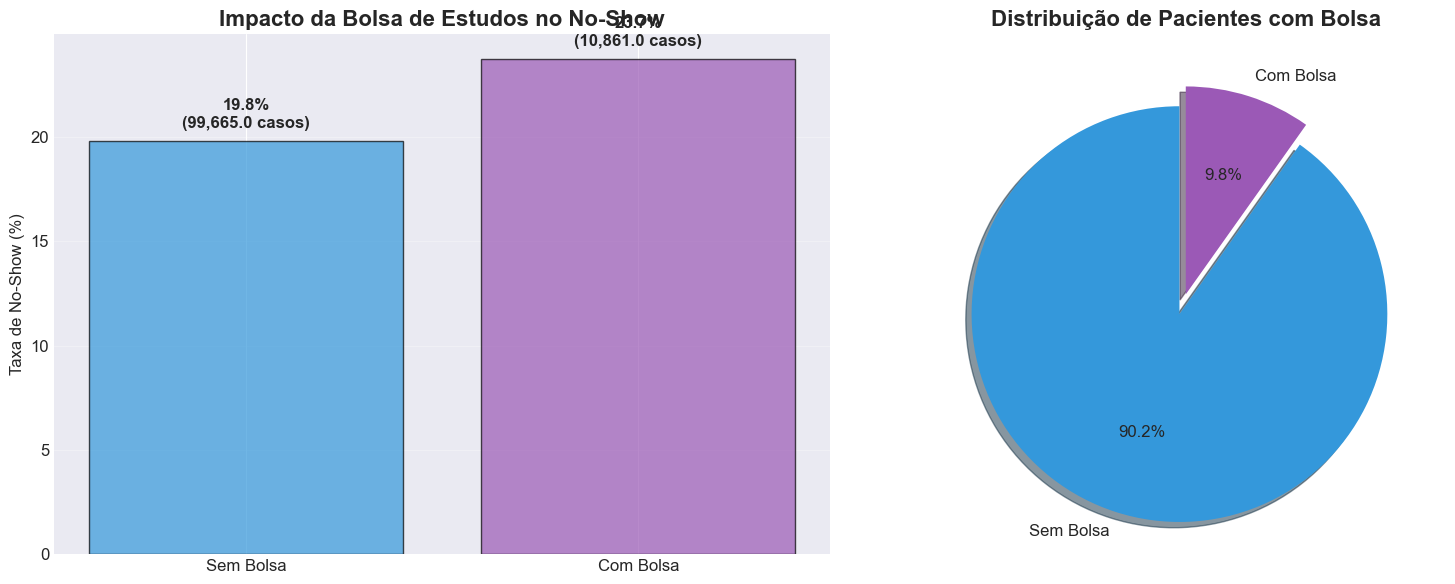

In [14]:
# Impacto da bolsa de estudos no no-show
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scholarship_noshow = df.groupby('SCHOLARSHIP')['NO-SHOW'].agg(['mean', 'count'])
scholarship_noshow['mean'] = scholarship_noshow['mean'] * 100
scholarship_labels = ['Sem Bolsa', 'Com Bolsa']

axes[0].bar(range(len(scholarship_noshow)), scholarship_noshow['mean'], 
           color=['#3498db', '#9b59b6'], edgecolor='black', alpha=0.7)
axes[0].set_xticks(range(len(scholarship_noshow)))
axes[0].set_xticklabels(scholarship_labels)
axes[0].set_ylabel('Taxa de No-Show (%)', fontsize=12)
axes[0].set_title('Impacto da Bolsa de Estudos no No-Show', fontsize=16, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, (idx, row) in enumerate(scholarship_noshow.iterrows()):
    axes[0].text(i, row['mean'] + 0.5, f"{row['mean']:.1f}%\n({row['count']:,} casos)", 
                ha='center', va='bottom', fontweight='bold')

scholarship_counts = df['SCHOLARSHIP'].value_counts()
axes[1].pie(scholarship_counts, labels=scholarship_labels, autopct='%1.1f%%', 
           colors=['#3498db', '#9b59b6'], explode=(0.1, 0), startangle=90, shadow=True)
axes[1].set_title('Distribuição de Pacientes com Bolsa', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## 🔥 10. Matriz de Correlação

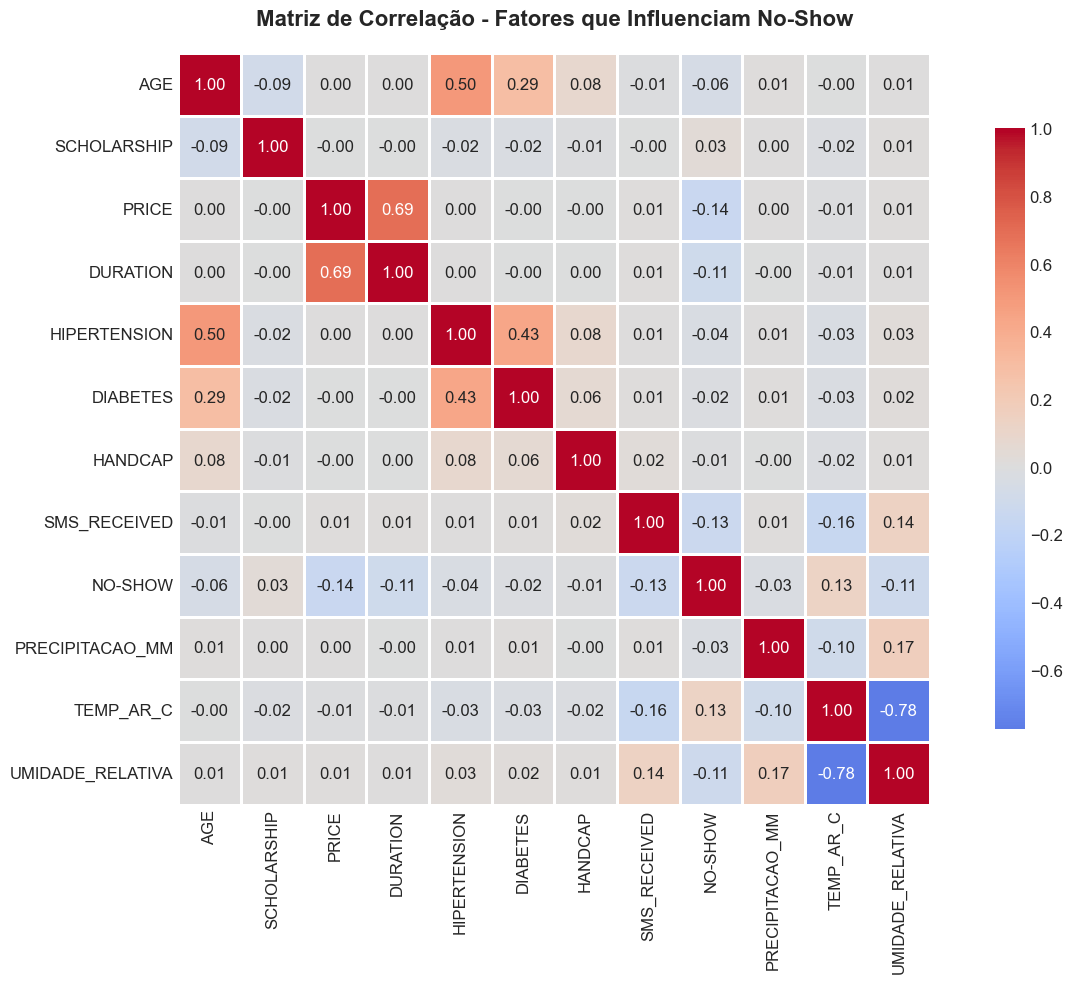


🔥 Correlações com NO-SHOW (ordenadas por força):
NO-SHOW             1.00
TEMP_AR_C           0.13
SCHOLARSHIP         0.03
HANDCAP            -0.01
DIABETES           -0.02
PRECIPITACAO_MM    -0.03
HIPERTENSION       -0.04
AGE                -0.06
DURATION           -0.11
UMIDADE_RELATIVA   -0.11
SMS_RECEIVED       -0.13
PRICE              -0.14
Name: NO-SHOW, dtype: float64


In [15]:
# Selecionar colunas numéricas para correlação
numeric_cols = ['AGE', 'SCHOLARSHIP', 'PRICE', 'DURATION', 'HIPERTENSION', 
                'DIABETES', 'HANDCAP', 'SMS_RECEIVED', 'NO-SHOW', 
                'PRECIPITACAO_MM', 'TEMP_AR_C', 'UMIDADE_RELATIVA']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - Fatores que Influenciam No-Show', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlações mais fortes com NO-SHOW
print("\n🔥 Correlações com NO-SHOW (ordenadas por força):")
correlations = corr_matrix['NO-SHOW'].sort_values(ascending=False)
print(correlations)

## 📈 11. Insights e Conclusões

In [16]:
print("="*80)
print("📊 RESUMO EXECUTIVO - ANÁLISE DE NO-SHOW")
print("="*80)

# Estatísticas gerais
total_appointments = len(df)
no_show_rate = df['NO-SHOW'].mean() * 100
show_rate = (1 - df['NO-SHOW'].mean()) * 100

print(f"\n📌 VISÃO GERAL:")
print(f"   Total de Agendamentos: {total_appointments:,}")
print(f"   Taxa de No-Show: {no_show_rate:.2f}%")
print(f"   Taxa de Comparecimento: {show_rate:.2f}%")

# Principais fatores identificados
print(f"\n🎯 PRINCIPAIS FATORES IDENTIFICADOS:")

# SMS
sms_impact = df.groupby('SMS_RECEIVED')['NO-SHOW'].mean()
sms_reduction = (sms_impact[0] - sms_impact[1]) * 100
print(f"\n   📱 SMS:")
print(f"      • Redução de {sms_reduction:.2f} pontos percentuais com SMS")
print(f"      • Sem SMS: {sms_impact[0]*100:.2f}% de no-show")
print(f"      • Com SMS: {sms_impact[1]*100:.2f}% de no-show")

# Gênero
gender_noshow = df.groupby('GENDER')['NO-SHOW'].mean() * 100
print(f"\n   👥 GÊNERO:")
for gender in gender_noshow.index:
    print(f"      • {gender}: {gender_noshow[gender]:.2f}% de no-show")

# Faixa etária com maior no-show
age_noshow = df.groupby('FAIXA_ETARIA')['NO-SHOW'].mean().sort_values(ascending=False)
print(f"\n   👶 IDADE:")
print(f"      • Faixa com maior no-show: {age_noshow.index[0]} ({age_noshow.values[0]*100:.2f}%)")
print(f"      • Faixa com menor no-show: {age_noshow.index[-1]} ({age_noshow.values[-1]*100:.2f}%)")

# Preço
price_noshow = df.groupby('FAIXA_PRECO')['NO-SHOW'].mean().sort_values(ascending=False)
print(f"\n   💰 PREÇO:")
print(f"      • Faixa com maior no-show: {price_noshow.index[0]} ({price_noshow.values[0]*100:.2f}%)")
print(f"      • Faixa com menor no-show: {price_noshow.index[-1]} ({price_noshow.values[-1]*100:.2f}%)")

# Serviço mais problemático
service_noshow = df.groupby('SERVICENAME')['NO-SHOW'].agg(['mean', 'count'])
service_noshow = service_noshow[service_noshow['count'] > 100]  # Apenas serviços com volume significativo
service_noshow = service_noshow.sort_values('mean', ascending=False)
print(f"\n   💆 SERVIÇOS:")
print(f"      • Maior no-show: {service_noshow.index[0]} ({service_noshow['mean'].values[0]*100:.2f}%)")
print(f"      • Menor no-show: {service_noshow.index[-1]} ({service_noshow['mean'].values[-1]*100:.2f}%)")

print(f"\n💡 RECOMENDAÇÕES:")
print(f"   1. ✅ Implementar envio automático de SMS para todos os agendamentos")
print(f"   2. 🎯 Focar em estratégias para reduzir no-show na faixa etária {age_noshow.index[0]}")
print(f"   3. 💰 Revisar política de preços para faixa {price_noshow.index[0]}")
print(f"   4. 🔔 Criar lembretes especiais para o serviço '{service_noshow.index[0]}'")
print(f"   5. 🌡️ Considerar fatores climáticos ao agendar procedimentos externos")

print("\n" + "="*80)

📊 RESUMO EXECUTIVO - ANÁLISE DE NO-SHOW

📌 VISÃO GERAL:
   Total de Agendamentos: 110,526
   Taxa de No-Show: 20.19%
   Taxa de Comparecimento: 79.81%

🎯 PRINCIPAIS FATORES IDENTIFICADOS:

   📱 SMS:
      • Redução de 10.87 pontos percentuais com SMS
      • Sem SMS: 27.57% de no-show
      • Com SMS: 16.70% de no-show

   👥 GÊNERO:
      • F: 20.31% de no-show
      • M: 19.97% de no-show

   👶 IDADE:
      • Faixa com maior no-show: 19-30 (24.71%)
      • Faixa com menor no-show: 60+ (15.20%)

   💰 PREÇO:
      • Faixa com maior no-show: R$0-50 (27.99%)
      • Faixa com menor no-show: R$151-200 (12.40%)

   💆 SERVIÇOS:
      • Maior no-show: DESIGN SIMPLES DE SOBRANCELHAS (30.62%)
      • Menor no-show: HIDROLIPO NA (11.42%)

💡 RECOMENDAÇÕES:
   1. ✅ Implementar envio automático de SMS para todos os agendamentos
   2. 🎯 Focar em estratégias para reduzir no-show na faixa etária 19-30
   3. 💰 Revisar política de preços para faixa R$0-50
   4. 🔔 Criar lembretes especiais para o serviço

## 💾 12. Exportar Resultados

In [17]:
# Criar relatório resumido para exportação
relatorio = {
    'Métrica': [
        'Total de Agendamentos',
        'Taxa de No-Show (%)',
        'Taxa de Comparecimento (%)',
        'Idade Média dos Pacientes',
        'Preço Médio dos Serviços (R$)',
        'Pacientes Únicos',
        'Serviços Oferecidos',
        'No-Show com SMS (%)',
        'No-Show sem SMS (%)'
    ],
    'Valor': [
        f"{len(df):,}",
        f"{df['NO-SHOW'].mean()*100:.2f}",
        f"{(1-df['NO-SHOW'].mean())*100:.2f}",
        f"{df['AGE'].mean():.1f}",
        f"{df['PRICE'].mean():.2f}",
        f"{df['PATIENTID'].nunique():,}",
        f"{df['SERVICENAME'].nunique()}",
        f"{df[df['SMS_RECEIVED']==1]['NO-SHOW'].mean()*100:.2f}",
        f"{df[df['SMS_RECEIVED']==0]['NO-SHOW'].mean()*100:.2f}"
    ]
}

df_relatorio = pd.DataFrame(relatorio)
print("\n📊 RELATÓRIO RESUMIDO:")
print(df_relatorio.to_string(index=False))

# Salvar relatório
# df_relatorio.to_csv('relatorio_beira_mar.csv', index=False)
# print("\n✅ Relatório salvo em 'relatorio_beira_mar.csv'")


📊 RELATÓRIO RESUMIDO:
                      Métrica   Valor
        Total de Agendamentos 110,526
          Taxa de No-Show (%)   20.19
   Taxa de Comparecimento (%)   79.81
    Idade Média dos Pacientes    37.1
Preço Médio dos Serviços (R$)  104.33
             Pacientes Únicos  62,298
          Serviços Oferecidos      11
          No-Show com SMS (%)   16.70
          No-Show sem SMS (%)   27.57


---

## 🎉 Fim da Análise

### Próximos Passos:
1. Implementar modelo preditivo de no-show
2. Criar dashboard interativo em Grafana
3. Automatizar envio de alertas para agendamentos de alto risco
4. Integrar com sistema de CRM da clínica

---